# Topographic composites: AE versus CE in the surface PV-gradient frame
This follows the current simplified `planetary_composite_tilt` layout: all profiles, shallow/deep comparison panels, and depth-coloured mean centrelines. Each day is translated to its fitted surface centre and then rotated **before compositing** into its own surface topographic-PV frame.

- **Along-gradient (x)**: positive towards that day's `PV_grad_topo_theta`.
- **Perpendicular (y)**: positive 90° anticlockwise from the gradient, giving a right-handed coordinate system. For a northward gradient, positive perpendicular is westward.

The reference direction is a geographic bearing clockwise from north. The model-grid angle is removed during rotation. A fixed surface frame is used throughout each day's profile, so changing local reference axes with depth cannot create apparent tilt. `PV_grad_topo_mag` validates that a nonzero vector exists; it does **not** weight the composite or scale distances. Eddy-days remain equally weighted.

The gradient generally points across isobaths, and its perpendicular runs along them. These axes follow the **signed PV gradient**, not a guaranteed offshore/onshore convention. In the local expression `-(f+ζ)∇h/h²`, the gradient points towards increasing depth when absolute vorticity is negative and reverses when it is positive. Nonlinear footprint averaging can further alter its alignment with the mean bathymetric gradient. The audit below reports this relationship without flipping signs or excluding such days.

Tilt is **surface-to-depth displacement** of the mean constituent centre (km). Its length can be smaller than the mean individual tilt distance through cancellation. Relative angles, if used, are 0° along +gradient and 90° along +perpendicular, anticlockwise in this plane; they are not geographic bearings. Bootstrap intervals resample entire eddies and describe sampling uncertainty, not ESP fitting error.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp
import seacofs_tilt_tools as tilt
pd.set_option('display.max_columns', 60)

# Reuse the dataset's directional-radius helper for the full composite refit.
DATASET_SRC = ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
if str(DATASET_SRC) not in sys.path:
    sys.path.insert(0, str(DATASET_SRC))
import composite_breakdown_tools as cbt

import planetary_composite_tools as pct

import topographic_composite_tools as tct

import composite_comparison_tools as ccomp


In [2]:
DOMINANCE_FACTOR = 2.0
ELLIPSE_FRAC = 1.0
MAX_TOPO_DEPTH_M = 3000.0
USE_PV_CACHE = True
SPLIT_DEPTH_M = 1000.0
SHELF_LON = 154.75  # on-shelf < threshold; off-shelf >= threshold
BOOTSTRAPS = 500
SEED = 731
MIN_PLOT_EDDIES = 2  # plotting threshold only; all estimates remain in tables
WIDTH_KM, RES_KM = 400., 10.
RUN_VELOCITY_COMPOSITES = True
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
surface = tilt.add_pv_gradient_terms(surface, grid, core_mean=True, frac=ELLIPSE_FRAC,
    surface_method='esp_gaussian', averaging='nonlinear', use_cache=USE_PV_CACHE)
vertical = tilt.load_vert(paths)
topographic = surface.loc[(surface.topo_plan_ratio >= np.log(DOMINANCE_FACTOR)) &
    (surface.h <= MAX_TOPO_DEPTH_M) & surface.Cyc.isin(['AE','CE'])].copy()
topographic = ccomp.shelf_classes(topographic, SHELF_LON)
# Audit reference frames before excluding undefined directions.
frame_audit = tct.reference_frames(topographic, grid.angle)
display(frame_audit.groupby(['Cyc','frame_status']).size().rename('eddy_days'))
frame_alignment = frame_audit.groupby('Cyc').agg(
    eddy_days=('Day','size'), valid_frames=('frame_valid','sum'),
    median_dot_downslope=('gradient_dot_downslope_cos','median'))
display(frame_alignment)
print('Dot with mean grad(h): +1 deeper-water aligned; -1 shallower-water aligned; 0 perpendicular.')
display(frame_audit.loc[frame_audit.frame_valid].assign(
    points_towards_deeper_water=lambda d: d.gradient_dot_downslope_cos.gt(0).where(d.gradient_dot_downslope_cos.notna())
).groupby(['Cyc','points_towards_deeper_water'],dropna=False).size().rename('eddy_days'))
topographic = frame_audit.loc[frame_audit.frame_valid].copy()
profile_audit, centred_profiles = pct.prepare_profiles(topographic, vertical, SPLIT_DEPTH_M)
display(profile_audit.groupby(['Cyc','profile_status'], dropna=False).size().rename('eddy_days'))
display(profile_audit.groupby(['Cyc','extent_group'],dropna=False).agg(
    eddy_days=('Day','size'), eddies=('Eddy','nunique'), median_max_depth=('max_fit_depth_m','median')))

display(profile_audit.groupby(['shelf_class','extent_group','Cyc'],dropna=False).agg(eddy_days=('Day','size'),eddies=('Eddy','nunique')))


Cyc  frame_status
AE   usable           8206
CE   usable          11865
Name: eddy_days, dtype: int64

,eddy_days,valid_frames,median_dot_downslope
Cyc,,,
AE,8206,8206,0.999542
CE,11865,11865,0.999499


Dot with mean grad(h): +1 deeper-water aligned; -1 shallower-water aligned; 0 perpendicular.


Cyc  points_towards_deeper_water
AE   True                            8206
CE   True                           11865
Name: eddy_days, dtype: int64

Cyc  profile_status      
AE   no valid surface fit      630
     usable                   7576
CE   no valid surface fit      717
     usable                  11148
Name: eddy_days, dtype: int64

eddy_days  eddies  median_max_depth
Cyc extent_group                                     
AE  deep               2743     241       1492.971178
    shallow            4833     350        327.440851
    NaN                 630     201               NaN
CE  deep               6163     564       1492.971178
    shallow            4985     532        515.416489
    NaN                 717     273               NaN

eddy_days  eddies
shelf_class extent_group Cyc                   
Off-shelf   deep         AE        2613     210
                         CE        3530     248
            shallow      AE        3512     262
                         CE        3281     262
            NaN          AE         384     142
                         CE         403     158
On-shelf    deep         AE         130      31
                         CE        2633     317
            shallow      AE        1321      88
                         CE        1704     272
            NaN          AE         246      59
                         CE         314     115

In [3]:
max_depth = (vertical.groupby(['Eddy','Day'], as_index=False)['Depth'].max()
             .rename(columns={'Depth':'max_profile_depth'}))

topographic = topographic.merge(max_depth, on=['Eddy','Day'], how='left')
topographic['max_profile_depth'] /= 1e3

d = topographic.max_profile_depth.value_counts().sort_index()
print(pd.DataFrame({
    'n': d,
    'frac': d/d.sum(),
    'cum_frac': d.cumsum()/d.sum()
}))

                      n      frac  cum_frac
max_profile_depth                          
0.010726            218  0.011643  0.011643
0.016383            122  0.006516  0.018159
0.022926             97  0.005181  0.023339
0.030444             88  0.004700  0.028039
0.039053             91  0.004860  0.032899
0.048898            109  0.005821  0.038720
0.060171            104  0.005554  0.044275
0.073128            153  0.008171  0.052446
0.088117            180  0.009613  0.062059
0.105616            239  0.012764  0.074824
0.126288            297  0.015862  0.090686
0.151066            333  0.017785  0.108470
0.181265            394  0.021043  0.129513
0.218755            485  0.025903  0.155416
0.266206            606  0.032365  0.187780
0.327441            851  0.045450  0.233230
0.407922            937  0.050043  0.283273
0.515416           1181  0.063074  0.346347
0.660806           1430  0.076373  0.422720
0.858918           1903  0.101634  0.524354
1.128898           2548  0.13608

## Depth-extent groups and reconstruction
`shallow` means an eddy-day's deepest valid fit is ≤ the split depth; `deep` means > it. The classification is made **before** reconstruction or display-depth restrictions. A track can contribute days to both groups as its observed extent changes. These are observed fit extents, not certified physical eddy bottoms: fitting failures can truncate profiles.

The `all` group is the baseline and overlaps the other two groups. Days receive equal weight, matching the breakdown notebook. By default the actual ESP velocity composites are computed, and centre statistics use precisely the levels that contributed finite velocity. Turning off reconstruction allows faster centre-only exploration, using valid fitted centres instead; that mode is explicitly labelled below.

The default topographic population matches the breakdown selection: `topo_plan_ratio >= log(2)` and footprint-mean water depth ≤ 3,000 m. No old tilt-magnitude/direction filter is applied. Undefined gradient frames are excluded explicitly in `frame_audit`; no extra gradient-coherence threshold is imposed.

For the velocity composite, each common-grid point is inverse-rotated to the original day's model coordinates, the original ESP field is evaluated there, and both velocity components are rotated back. This rotates ellipse geometry and velocities together without spatial interpolation or averaging ellipse parameters. The composite plane has x = along-gradient, y = perpendicular. Bathymetric masking is not added; these remain idealised ESP reconstructions.


In [4]:
a = np.arange(-WIDTH_KM/2, WIDTH_KM/2 + RES_KM/2, RES_KM)
X, Y = np.meshgrid(a, a)
results = {}
for cohort in ['all','shallow','deep']:
    for cyc in ['AE','CE']:
        selected = profile_audit.loc[profile_audit.Cyc.eq(cyc) & profile_audit.profile_status.eq('usable')].copy()
        if cohort != 'all': selected = selected.loc[selected.extent_group.eq(cohort)]
        if selected.empty:
            print(cohort,cyc,': no usable profiles'); continue
        if RUN_VELOCITY_COMPOSITES:
            u,v,depths,counts,support,audit,members = tct.composite_days(
                selected,vertical,X,Y,esp=esp)
            field = dict(u=u,v=v,depths=depths,counts=counts,support=support,audit=audit)
        else:
            members = centred_profiles.merge(selected[['Eddy','Day']],on=['Eddy','Day'],validate='many_to_one')[['Eddy','Day','Depth','xc','yc']]
            members = tct.rotate_members(members, selected)
            field = {}
        stats, boot = tct.summarise(members,BOOTSTRAPS,SEED)
        results[cohort,cyc] = dict(members=members,stats=stats,bootstrap=boot,**field)
        print(cohort,cyc,':',len(members),'contributing levels;',members.Eddy.nunique(),'eddies')
if not results: raise ValueError('No usable topographic profiles')
print('Mode:', 'finite ESP contributors' if RUN_VELOCITY_COMPOSITES else 'valid fitted centres only')
centre_stats = pd.concat([r['stats'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
centre_members = pd.concat([r['members'].assign(cohort=g,Cyc=c) for (g,c),r in results.items()],ignore_index=True)
display(centre_stats)


Reconstructed 100 eddy-days in their surface PV frames
Reconstructed 200 eddy-days in their surface PV frames
Reconstructed 300 eddy-days in their surface PV frames
Reconstructed 400 eddy-days in their surface PV frames
Reconstructed 500 eddy-days in their surface PV frames
Reconstructed 600 eddy-days in their surface PV frames
Reconstructed 700 eddy-days in their surface PV frames
Reconstructed 800 eddy-days in their surface PV frames
Reconstructed 900 eddy-days in their surface PV frames
Reconstructed 1000 eddy-days in their surface PV frames
Reconstructed 1100 eddy-days in their surface PV frames
Reconstructed 1200 eddy-days in their surface PV frames
Reconstructed 1300 eddy-days in their surface PV frames
Reconstructed 1400 eddy-days in their surface PV frames
Reconstructed 1500 eddy-days in their surface PV frames
Reconstructed 1600 eddy-days in their surface PV frames
Reconstructed 1700 eddy-days in their surface PV frames
Reconstructed 1800 eddy-days in their surface PV frames
R

,Depth,n_eddy_days,n_eddies,mean_along,mean_perp,var_along,var_perp,cov_along_perp,std_along,std_perp,mean_along_ci_low,mean_along_ci_high,mean_perp_ci_low,mean_perp_ci_high,bootstrap_valid_draws,distance_km,mean_member_distance_km,coherence,distance_ci_low,distance_ci_high,relative_angle_deg,cohort,Cyc
0,0.000000,7576,382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500,0.000000,0.000000,NaN,0.000000,0.000000,NaN,all,AE
1,5.879627,7576,382,0.220382,-0.378888,26.872193,37.538607,1.162544,5.183840,6.126876,0.038391,0.400201,-0.610977,-0.153323,500,0.438320,5.300134,0.082700,0.228234,0.662629,300.184593,all,AE
2,10.725783,7576,382,0.408955,-0.441905,47.223900,62.027083,2.567760,6.871965,7.875727,0.138027,0.659724,-0.733217,-0.129022,500,0.602100,6.983291,0.086220,0.307728,0.906123,312.782299,all,AE
3,16.383097,7477,381,0.390863,-0.451410,55.845392,67.325280,1.478295,7.472977,8.205198,0.075432,0.688837,-0.774592,-0.110215,500,0.597114,7.970481,0.074916,0.312766,0.973498,310.888322,all,AE
4,22.925581,7428,381,0.420033,-0.410761,63.139764,75.506135,2.543704,7.946053,8.689427,0.042015,0.764746,-0.749976,-0.053827,500,0.587497,8.731942,0.067281,0.251219,0.974527,315.639427,all,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,2568.677466,1414,309,48.535283,1.314294,1753.956476,1832.084181,21.776452,41.880264,42.802852,43.637775,53.902520,-3.713461,6.191714,500,48.553074,67.909981,0.714962,43.677407,54.041102,1.551141,deep,CE
158,3252.716389,726,201,61.962645,2.116445,1592.091910,2162.032188,-76.319428,39.901026,46.497658,56.553044,67.417563,-4.468622,8.703601,500,61.998780,80.669396,0.768554,56.620514,67.511667,1.956279,deep,CE
159,3930.053268,379,127,75.776871,1.035950,1166.579210,2093.297173,-139.538516,34.155222,45.752565,70.465506,81.678700,-5.484437,7.639124,500,75.783952,87.553749,0.865571,70.542705,81.725778,0.783245,deep,CE
160,4460.447022,281,92,77.812473,-2.173166,1132.381310,2083.674993,-65.633612,33.650874,45.647289,71.411292,85.046221,-10.033286,5.360460,500,77.842813,89.186068,0.872814,71.525061,85.224241,358.400245,deep,CE


## Composite tilt and depth support
Component bands are 95% pointwise whole-eddy bootstrap intervals; the covariance and variance columns quantify individual-day spread. The distance band bootstraps the **norm of each resampled mean vector**, preserving x–y covariance. Close to zero this nonnegative norm is biased upward, so use the component intervals to assess whether the mean displacement differs from zero. Direction is undefined for a zero vector.

`coherence = length(mean vector) / mean(length)` approaches zero when constituent tilts cancel and one when they point together. Sparse depths remain in the tables; plotting support is controlled above.


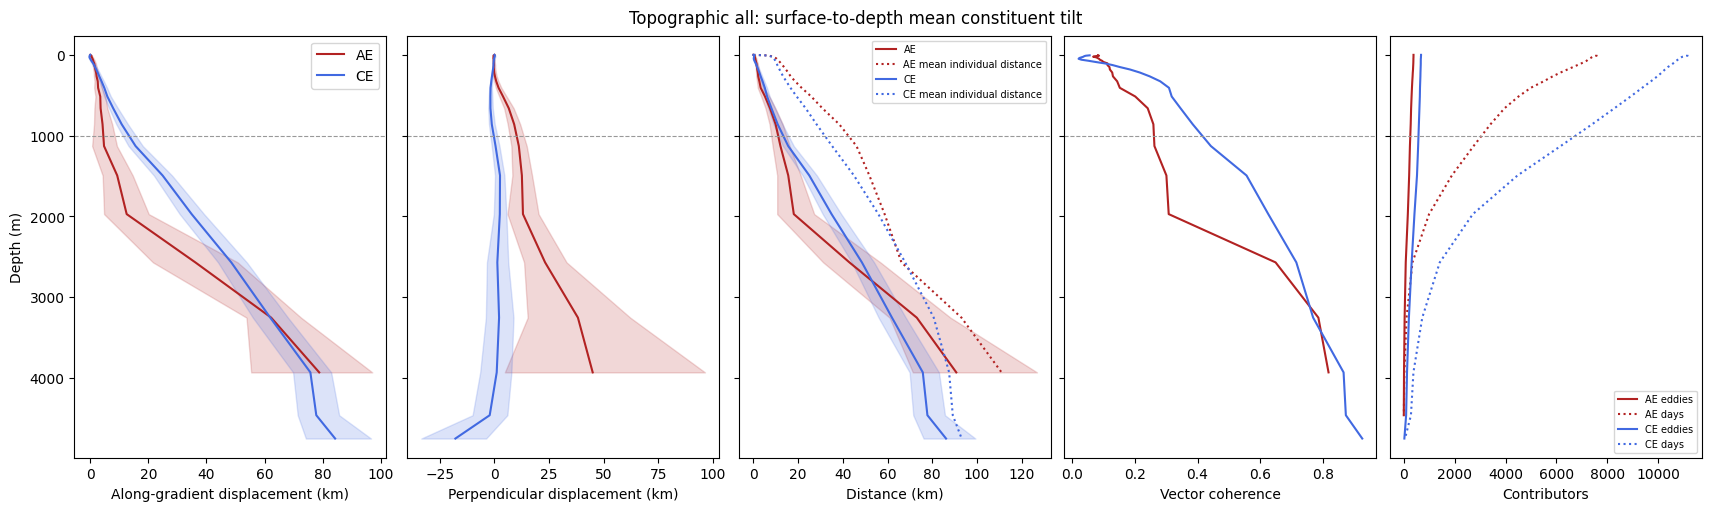

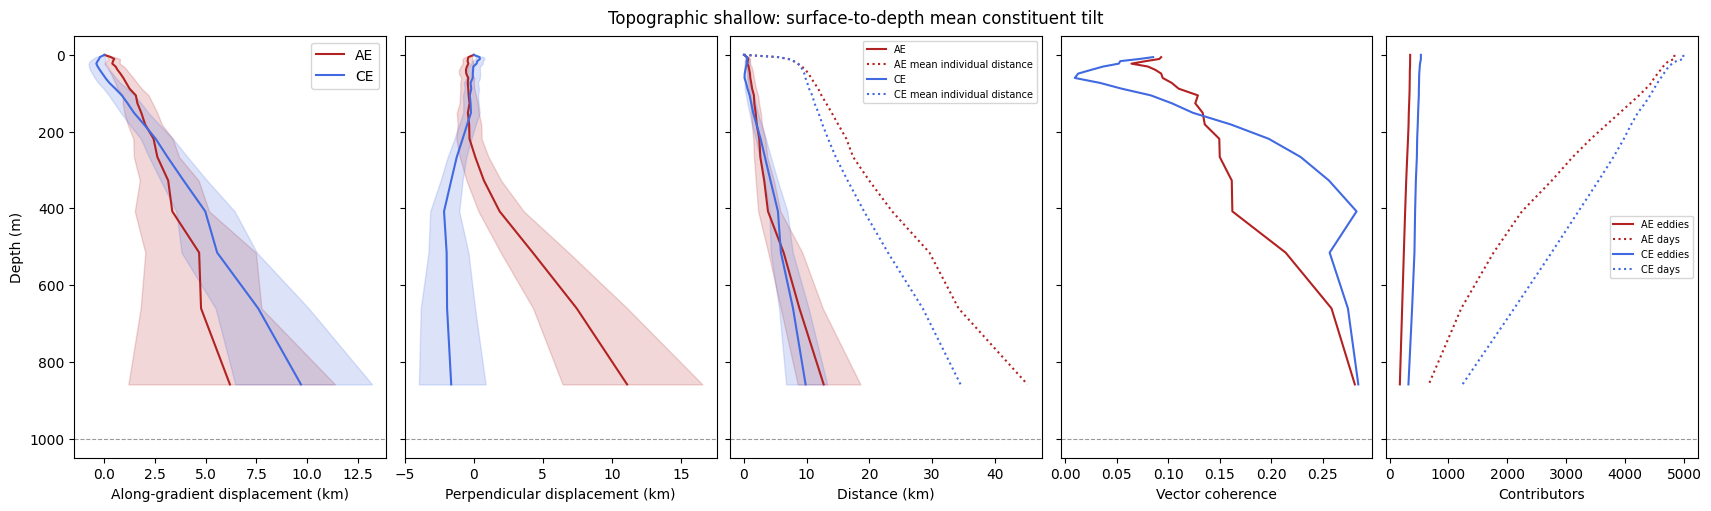

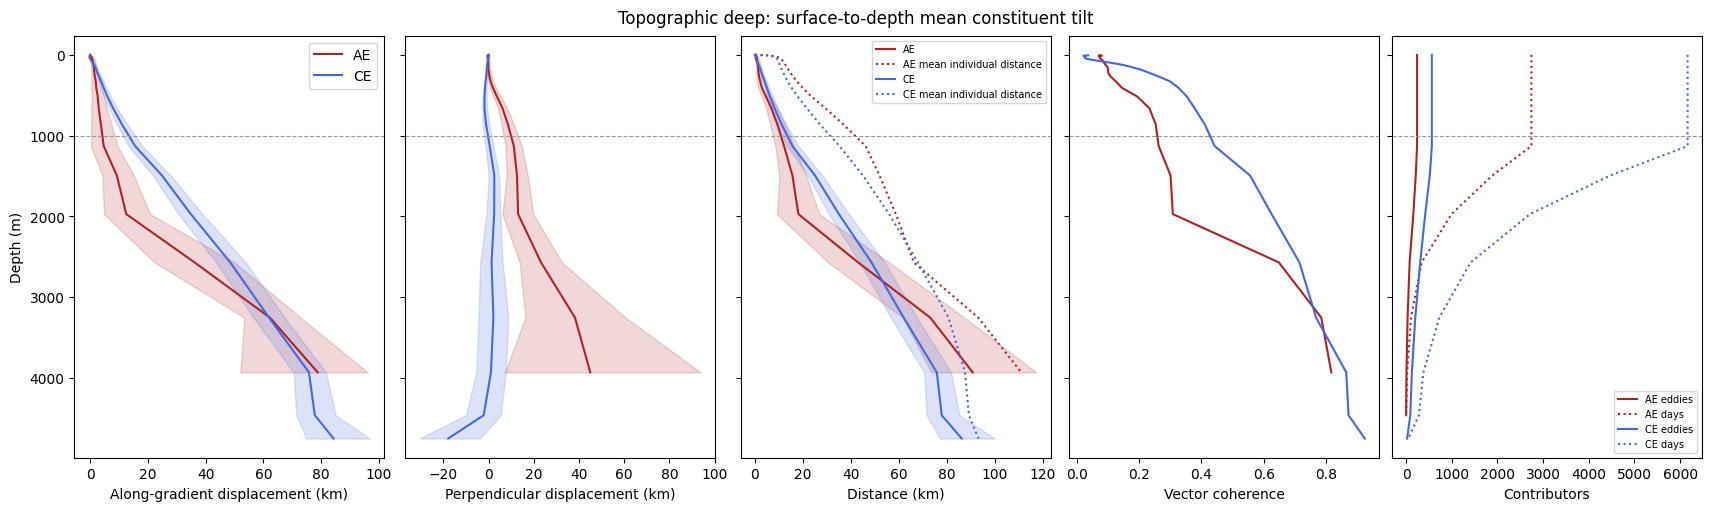

In [5]:
COLORS = {'AE':'firebrick','CE':'royalblue'}
for cohort in ['all','shallow','deep']:
    fig,axs=plt.subplots(1,5,figsize=(17,5),sharey=True,constrained_layout=True)
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for ax,col,lo,hi in [(axs[0],'mean_along','mean_along_ci_low','mean_along_ci_high'),
                             (axs[1],'mean_perp','mean_perp_ci_low','mean_perp_ci_high'),
                             (axs[2],'distance_km','distance_ci_low','distance_ci_high')]:
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
        axs[2].plot(s.mean_member_distance_km.where(ok),s.Depth,':',color=COLORS[cyc],label=f'{cyc} mean individual distance')
        axs[3].plot(s.coherence.where(ok),s.Depth,color=COLORS[cyc])
        axs[4].plot(s.n_eddies,s.Depth,color=COLORS[cyc],label=f'{cyc} eddies')
        axs[4].plot(s.n_eddy_days,s.Depth,':',color=COLORS[cyc],label=f'{cyc} days')
    for ax,label in zip(axs,['Along-gradient displacement (km)','Perpendicular displacement (km)','Distance (km)','Vector coherence','Contributors']):
        ax.set_xlabel(label); ax.axhline(SPLIT_DEPTH_M,color='.6',ls='--',lw=.8)
    axs[0].set_ylabel('Depth (m)'); axs[0].invert_yaxis()
    axs[0].legend();axs[2].legend(fontsize=7);axs[4].legend(fontsize=7)
    fig.suptitle(f'Topographic {cohort}: surface-to-depth mean constituent tilt')
    plt.show()


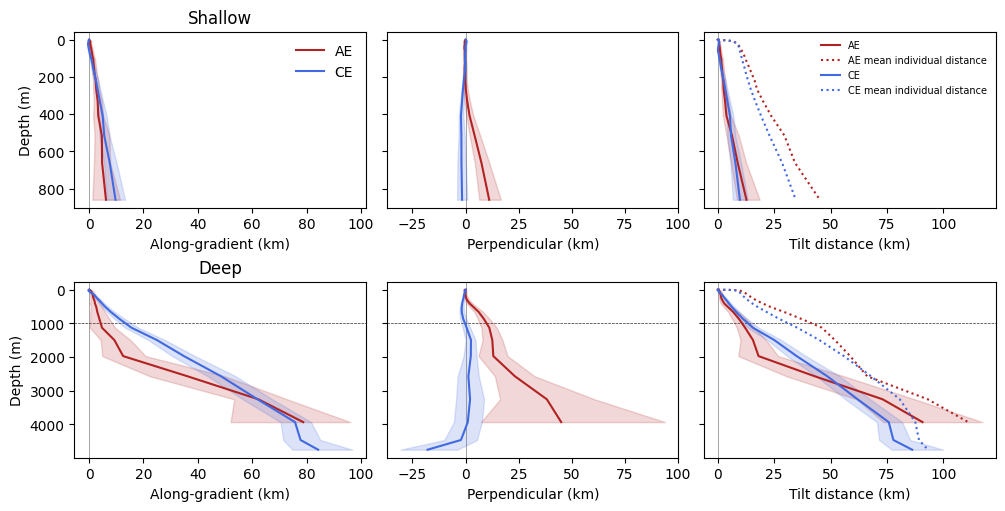

In [21]:
fig,axs=plt.subplots(2,3,figsize=(10,5),sharey=False,constrained_layout=True)
for c, cohort in enumerate(['shallow','deep']):
    for cyc in ['AE','CE']:
        if (cohort,cyc) not in results: continue
        s=results[cohort,cyc]['stats'].copy()
        ok=s.n_eddies.ge(MIN_PLOT_EDDIES)
        for r, (ax,col,lo,hi) in enumerate([(axs[c,0],'mean_along','mean_along_ci_low','mean_along_ci_high'),
                             (axs[c,1],'mean_perp','mean_perp_ci_low','mean_perp_ci_high'),
                             (axs[c,2],'distance_km','distance_ci_low','distance_ci_high')]):
            ax.plot(s[col].where(ok),s.Depth,color=COLORS[cyc],label=cyc)
            ax.fill_betweenx(s.Depth,s[lo].where(ok),s[hi].where(ok),color=COLORS[cyc],alpha=.18)
            if r!=0: ax.tick_params(labelleft=False)
            if c==1: ax.axhline(SPLIT_DEPTH_M,color='k', zorder=0, alpha=.5, ls='--',lw=.5)
            ax.set_ylabel('Depth (m)' if r == 0 else ''); 
            if r == 0:
                ax.set_xlabel('Along-gradient (km)')
            if r == 1:
                ax.set_xlabel('Perpendicular (km)')
            if r == 2:
                ax.set_xlabel('Tilt distance (km)')
                ax.plot(s.mean_member_distance_km.where(ok),s.Depth,':',color=COLORS[cyc],label=f'{cyc} mean individual distance')
                if cohort=='shallow': ax.legend(frameon=False, fontsize=7)
for i,cohort in enumerate(['shallow','deep']): axs[i,0].set_title(cohort.capitalize())
axs[0,0].legend(frameon=False)
for j in range(3):
    xlim = (min(ax.get_xlim()[0] for ax in axs[:,j]),
            max(ax.get_xlim()[1] for ax in axs[:,j]))
    [ax.set_xlim(xlim) for ax in axs[:,j]]
for ax in axs.flat: ax.invert_yaxis(); ax.axvline(0,lw=.5,color='k', zorder=0, alpha=.5)

plt.show()


In [ ]:
#### Inlcude same plot as above but splitting .Ro.abs()<.5 and .Ro.abs()=>.5 i.e. lo and high Robssby number



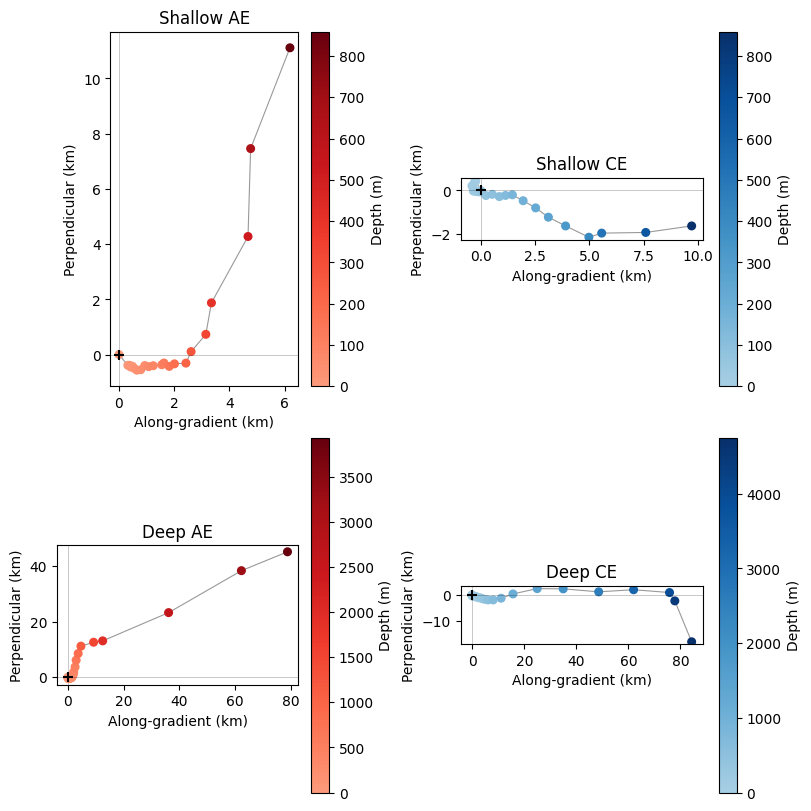

In [7]:
from matplotlib.colors import LinearSegmentedColormap

fig, axs = plt.subplots(2,2,figsize=(8,8),constrained_layout=True)

for i,cohort in enumerate(['shallow','deep']):
    for j,cyc in enumerate(['AE','CE']):
        ax=axs[i,j]
        if (cohort,cyc) not in results: continue

        s=results[cohort,cyc]['stats'].copy()
        s=s[s.n_eddies.ge(MIN_PLOT_EDDIES)].dropna(subset=['mean_along','mean_perp','Depth'])
        # cmap=plt.cm.Reds[.45,.95] if cyc=='AE' else plt.cm.Blues
        base = plt.cm.Reds if cyc == 'AE' else plt.cm.Blues
        cmap = LinearSegmentedColormap.from_list(
            f'{cyc}_cmap', base(np.linspace(.35, 1, 256))
        )
        if s.empty:
            ax.text(.5,.5,'Insufficient support',ha='center',transform=ax.transAxes)
            ax.set_title(f'{cohort.capitalize()} {cyc}');continue
        norm=plt.Normalize(s.Depth.min(),s.Depth.max())

        ax.plot(s.mean_along,s.mean_perp,color='0.6',lw=.8,zorder=0)
        sc=ax.scatter(s.mean_along,s.mean_perp,c=s.Depth,cmap=cmap,norm=norm,s=30)

        ax.scatter(0,0,c='k',marker='+',s=60)
        ax.axhline(0,color='k',lw=.5,alpha=.3)
        ax.axvline(0,color='k',lw=.5,alpha=.3)
        ax.set_aspect('equal', 'box')
        ax.set_title(f'{cohort.capitalize()} {cyc}')
        ax.set(xlabel='Along-gradient (km)',ylabel='Perpendicular (km)')
        fig.colorbar(sc,ax=ax,label='Depth (m)')

plt.show()

## Velocity composites in the same rotated frame
These maps use the actual rotated velocities. The marked mean centre is in along-gradient/perpendicular coordinates, matching the centreline plots. A single speed colour scale is shared between AE and CE. Use an exact fitted depth; no nearest-depth substitution is made.


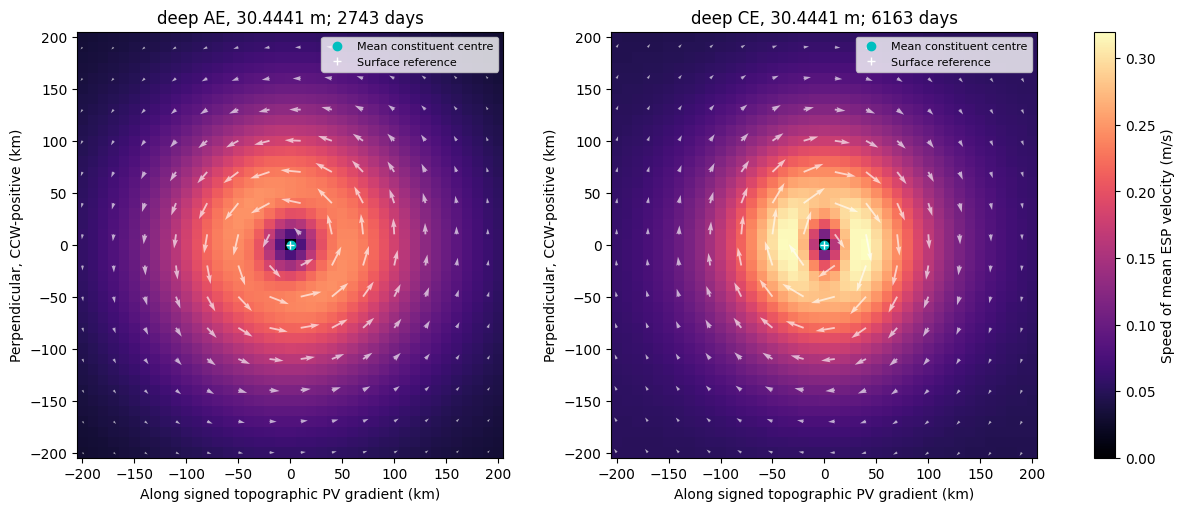

In [8]:
MAP_COHORT = 'deep'  # 'all', 'shallow', or 'deep'
MAP_DEPTH_M = np.abs(grid.z_r[150,150,5])
fields=[]
for cyc in ['AE','CE']:
    r=results.get((MAP_COHORT,cyc))
    if r is not None and 'u' in r and MAP_DEPTH_M in r['depths']:
        k=int(np.flatnonzero(r['depths']==MAP_DEPTH_M)[0])
        speed=np.hypot(r['u'][...,k],r['v'][...,k])
        if np.isfinite(speed).any():fields.append((cyc,r,k,speed))
if fields:
    fig,axs=plt.subplots(1,len(fields),figsize=(6*len(fields),5),squeeze=False,constrained_layout=True)
    vmax=max(np.nanmax(f) for _,_,_,f in fields)
    for ax,(cyc,r,k,speed) in zip(axs.flat,fields):
        im=ax.pcolormesh(X,Y,speed,cmap='magma',vmin=0,vmax=vmax,shading='auto')
        step=max(1,len(a)//11)
        sl=(slice(None,None,step),slice(None,None,step))
        ax.quiver(X[sl],Y[sl],r['u'][...,k][sl],r['v'][...,k][sl],color='white',alpha=.65,
                  scale=max(vmax,1e-12)*15,scale_units='width')
        m=r['members'].loc[lambda d:d.Depth.eq(MAP_DEPTH_M)]
        ax.plot(m.along_km.mean(),m.perp_km.mean(),'co',label='Mean constituent centre')
        ax.plot(0,0,'w+',label='Surface reference')
        ax.set(aspect='equal',xlabel='Along signed topographic PV gradient (km)',
            ylabel='Perpendicular, CCW-positive (km)',title=f'{MAP_COHORT} {cyc}, {MAP_DEPTH_M:g} m; {len(m)} days')
        ax.legend(fontsize=8)
    fig.colorbar(im,ax=list(axs.flat),label='Speed of mean ESP velocity (m/s)')
    plt.show()
else:
    print('No velocity composite at that exact depth/cohort; check support or enable RUN_VELOCITY_COMPOSITES.')


## Tables for further analysis
`centre_stats` contains mean along/perpendicular displacement, sample variances, covariance (`cov_along_perp`), bootstrap confidence intervals, distances, relative angles and support. `centre_members` retains original model-grid displacements (`xc`, `yc`) alongside rotated displacements and each day's frame angle. `results` also contains bootstrap samples and velocity/support arrays.

The shallow/deep split refers to **each day's deepest valid fit**, not a certified eddy bottom. The all group overlaps the two split groups. Changing membership with depth can bend the mean centreline; the depth support panels remain essential. Optional exports below overwrite only these labelled topographic outputs.


In [9]:
SAVE_TABLES = False
if SAVE_TABLES:
    out=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/topographic_composite_tilt')
    out.mkdir(parents=True,exist_ok=True)
    for name in ['frame_audit','profile_audit','centre_members','centre_stats']:
        globals()[name].to_parquet(out/f'{name}.parquet',index=False)
    (out/'settings.json').write_text(json.dumps(dict(dominance_factor=DOMINANCE_FACTOR,
        max_topo_depth_m=MAX_TOPO_DEPTH_M,split_depth_m=SPLIT_DEPTH_M,
        grid_angle_rad=float(grid.angle),surface_frame='PV_grad_topo_theta',
        x='positive signed gradient',y='90 degrees anticlockwise from x',
        tilt='surface-to-depth',weighting='equal eddy-day',bootstraps=BOOTSTRAPS,seed=SEED,
        run_velocity_composites=RUN_VELOCITY_COMPOSITES),indent=2))
    print(out)


## Additional on-shelf / off-shelf split
Use the earlier topographic notebook's `shelf_class` rule: **on-shelf longitude < 154.75°E; off-shelf longitude ≥ 154.75°E**. This classification uses each eddy-day's surface longitude, before compositing. A moving eddy may contribute days to both populations; the split is not a permanent track label. Missing longitude is explicitly `Unknown`: those days remain in the combined population but enter neither shelf group.

Each shelf population retains the all/shallow/deep cohorts and the same signed surface-PV rotation. `shelf_results['On-shelf'][('deep','CE')]`, for example, contains that population's own reconstructed composite, counts, centres and bootstrap statistics. Existing `results` remains the combined population. Combined and split populations overlap and must not be pooled as independent samples.


Reconstructed 100 eddy-days in their surface PV frames
Reconstructed 200 eddy-days in their surface PV frames
Reconstructed 300 eddy-days in their surface PV frames
Reconstructed 400 eddy-days in their surface PV frames
Reconstructed 500 eddy-days in their surface PV frames
Reconstructed 600 eddy-days in their surface PV frames
Reconstructed 700 eddy-days in their surface PV frames
Reconstructed 800 eddy-days in their surface PV frames
Reconstructed 900 eddy-days in their surface PV frames
Reconstructed 1000 eddy-days in their surface PV frames
Reconstructed 1100 eddy-days in their surface PV frames
Reconstructed 1200 eddy-days in their surface PV frames
Reconstructed 1300 eddy-days in their surface PV frames
Reconstructed 1400 eddy-days in their surface PV frames
On-shelf, all, AE: 90 contributing eddies
Reconstructed 100 eddy-days in their surface PV frames
Reconstructed 200 eddy-days in their surface PV frames
Reconstructed 300 eddy-days in their surface PV frames
Reconstructed 400 

,Depth,n_eddy_days,n_eddies,mean_along,mean_perp,var_along,var_perp,cov_along_perp,std_along,std_perp,mean_along_ci_low,mean_along_ci_high,mean_perp_ci_low,mean_perp_ci_high,bootstrap_valid_draws,distance_km,mean_member_distance_km,coherence,distance_ci_low,distance_ci_high,relative_angle_deg,population,cohort,Cyc
0,0.000000,7576,382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,500,0.000000,0.000000,NaN,0.000000,0.000000,NaN,All shelves,all,AE
1,5.879627,7576,382,0.220382,-0.378888,26.872193,37.538607,1.162544,5.183840,6.126876,0.038391,0.400201,-0.610977,-0.153323,500,0.438320,5.300134,0.082700,0.228234,0.662629,300.184593,All shelves,all,AE
2,10.725783,7576,382,0.408955,-0.441905,47.223900,62.027083,2.567760,6.871965,7.875727,0.138027,0.659724,-0.733217,-0.129022,500,0.602100,6.983291,0.086220,0.307728,0.906123,312.782299,All shelves,all,AE
3,16.383097,7477,381,0.390863,-0.451410,55.845392,67.325280,1.478295,7.472977,8.205198,0.075432,0.688837,-0.774592,-0.110215,500,0.597114,7.970481,0.074916,0.312766,0.973498,310.888322,All shelves,all,AE
4,22.925581,7428,381,0.420033,-0.410761,63.139764,75.506135,2.543704,7.946053,8.689427,0.042015,0.764746,-0.749976,-0.053827,500,0.587497,8.731942,0.067281,0.251219,0.974527,315.639427,All shelves,all,AE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,2568.677466,652,135,49.263026,-0.447054,2450.418248,2521.675327,157.447914,49.501699,50.216285,40.561554,59.146533,-9.431321,8.204007,500,49.265054,78.801975,0.625175,40.886560,59.424822,359.480064,Off-shelf,deep,CE
480,3252.716389,348,88,54.852927,3.290380,2149.278950,2677.506683,232.274933,46.360317,51.744630,45.094308,65.067995,-8.640979,13.560727,500,54.951526,82.462905,0.666379,45.419219,65.623211,3.432802,Off-shelf,deep,CE
481,3930.053268,69,29,86.938599,10.908308,1798.501513,3533.889021,920.275988,42.408743,59.446522,68.518479,104.571859,-8.936963,29.636702,500,87.620267,108.099134,0.810555,69.694948,106.742007,7.151609,Off-shelf,deep,CE
482,4460.447022,28,12,83.472770,8.314625,2556.877885,5659.794213,2561.391886,50.565580,75.231604,42.605480,113.455502,-46.855878,41.182498,500,83.885853,117.147561,0.716070,55.319347,118.184962,5.688402,Off-shelf,deep,CE


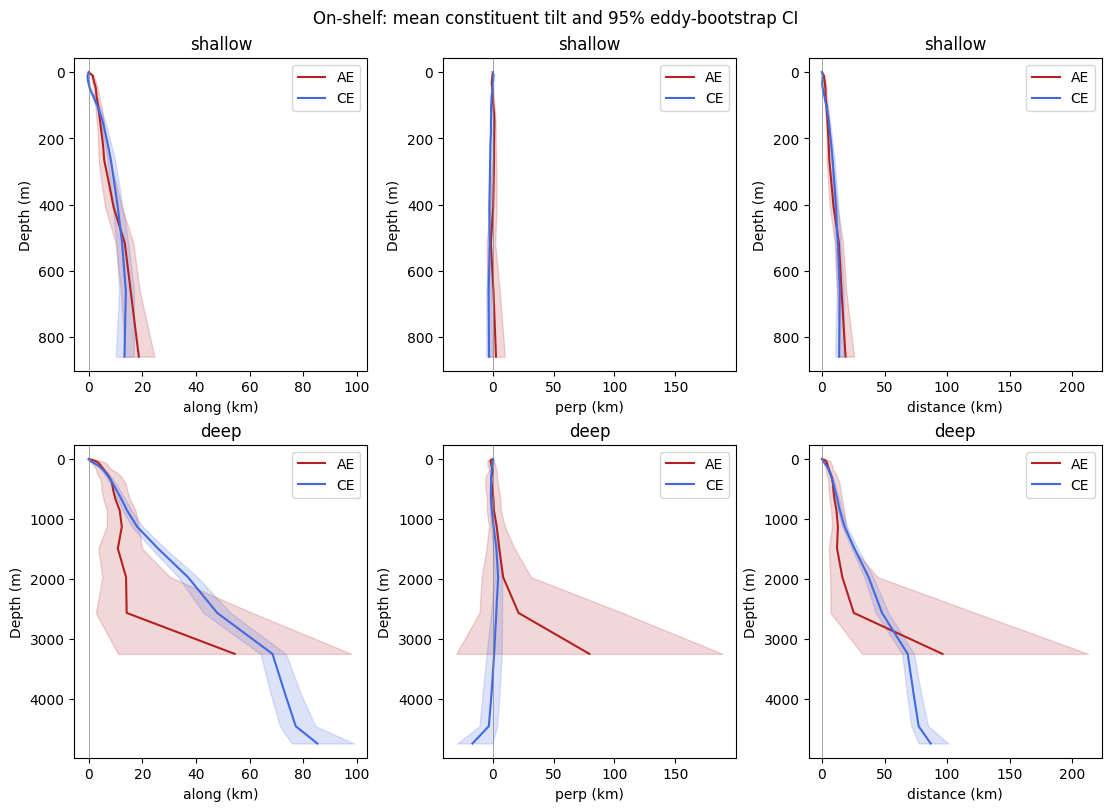

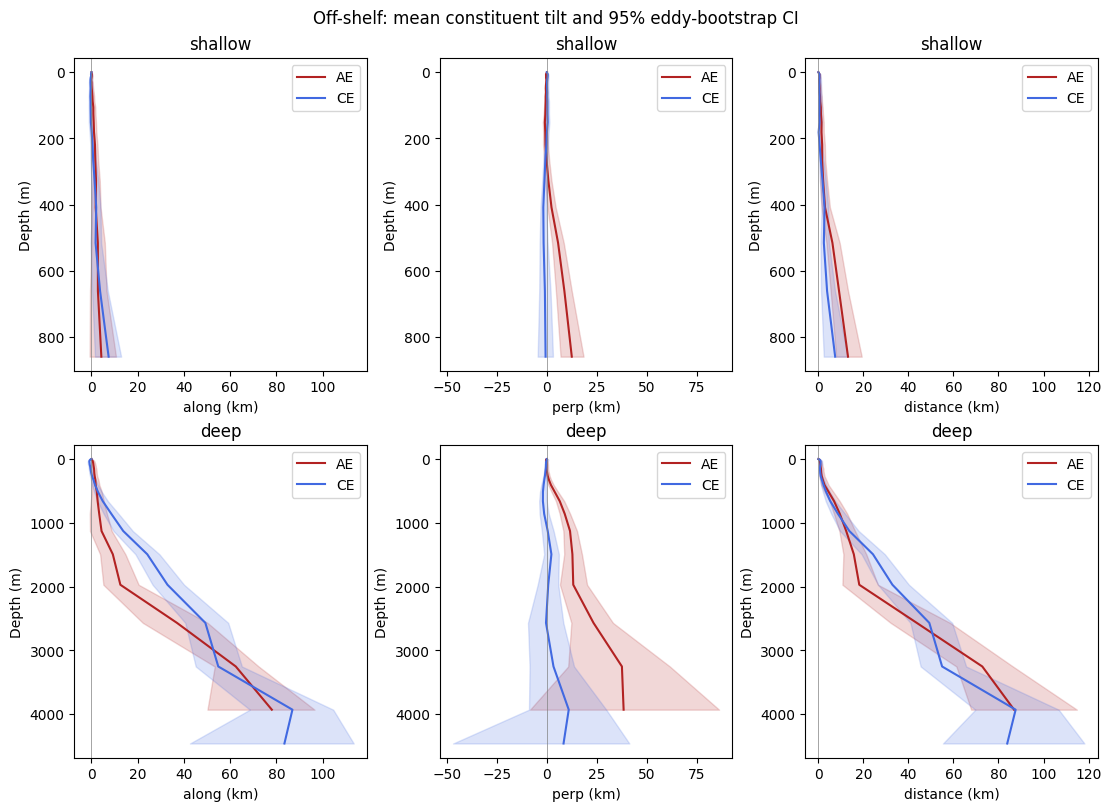

In [10]:
shelf_results = {'All shelves': results}
shelf_results.update(ccomp.shelf_composites(
    profile_audit, centred_profiles, vertical, X, Y, esp,
    velocity=RUN_VELOCITY_COMPOSITES, n_boot=BOOTSTRAPS, seed=SEED,
))
comparison_sets = shelf_results
shelf_centre_stats = pd.concat([
    r['stats'].assign(population=pop,cohort=cohort,Cyc=cyc)
    for pop,rs in comparison_sets.items() for (cohort,cyc),r in rs.items()
],ignore_index=True)
display(shelf_centre_stats)
for population in ['On-shelf','Off-shelf']:
    ccomp.plot_tilt_comparison(population,shelf_results[population],min_eddies=MIN_PLOT_EDDIES)
    plt.show()


### Tilt distance: comparable reference and deepest supported level
`tilt_summary` reports the **length of the mean constituent displacement vector**, with its pointwise eddy-bootstrap confidence interval and depth-specific support. It also retains the mean individual displacement length as a separate quantity.

For the first comparison, choose one **shared exact fitted depth** across all available shallow/deep AE/CE groups (including shelf groups in the topographic notebook). The closest common level to `SUMMARY_TARGET_DEPTH_M` is used only within `SUMMARY_DEPTH_TOLERANCE_M`; its actual depth is shown. If none exists, the comparison is explicitly unavailable. There is no depth interpolation or separate nearest-depth choice per group.

The second comparison reports each group's deepest level with at least `MIN_PLOT_EDDIES` contributors. These endpoint distances describe their own sampled extent; they are not distances at equal depths, nor a mean of each eddy's bottom displacement. Changing membership with depth and fit truncation still apply. Confidence intervals are pointwise, not simultaneous bands or uncertainty in the chosen endpoint.


,population,cohort,Cyc,summary,total_eddy_days,total_eddies,Depth,distance_km,ci_low,ci_high,mean_member_distance_km,n_eddy_days,n_eddies,status
0,All shelves,shallow,AE,Shared reference depth,4833,350,858.918,12.721,8.575,18.581,45.228,665,175,ok
1,All shelves,shallow,AE,Deepest supported depth,4833,350,858.918,12.721,8.575,18.581,45.228,665,175,ok
2,All shelves,shallow,CE,Shared reference depth,4985,532,858.918,9.835,6.728,13.280,34.555,1238,321,ok
3,All shelves,shallow,CE,Deepest supported depth,4985,532,858.918,9.835,6.728,13.280,34.555,1238,321,ok
4,All shelves,deep,AE,Shared reference depth,2743,241,858.918,9.301,6.265,12.463,36.750,2743,241,ok
5,All shelves,deep,AE,Deepest supported depth,2743,241,3930.053,90.755,73.492,117.329,111.002,23,9,ok
6,All shelves,deep,CE,Shared reference depth,6163,564,858.918,11.083,9.296,13.001,26.994,6163,564,ok
7,All shelves,deep,CE,Deepest supported depth,6163,564,4748.918,86.173,77.114,99.934,93.153,48,23,ok
8,On-shelf,shallow,AE,Shared reference depth,1321,88,858.918,18.850,13.762,25.700,30.168,89,35,ok
9,On-shelf,shallow,AE,Deepest supported depth,1321,88,858.918,18.850,13.762,25.700,30.168,89,35,ok


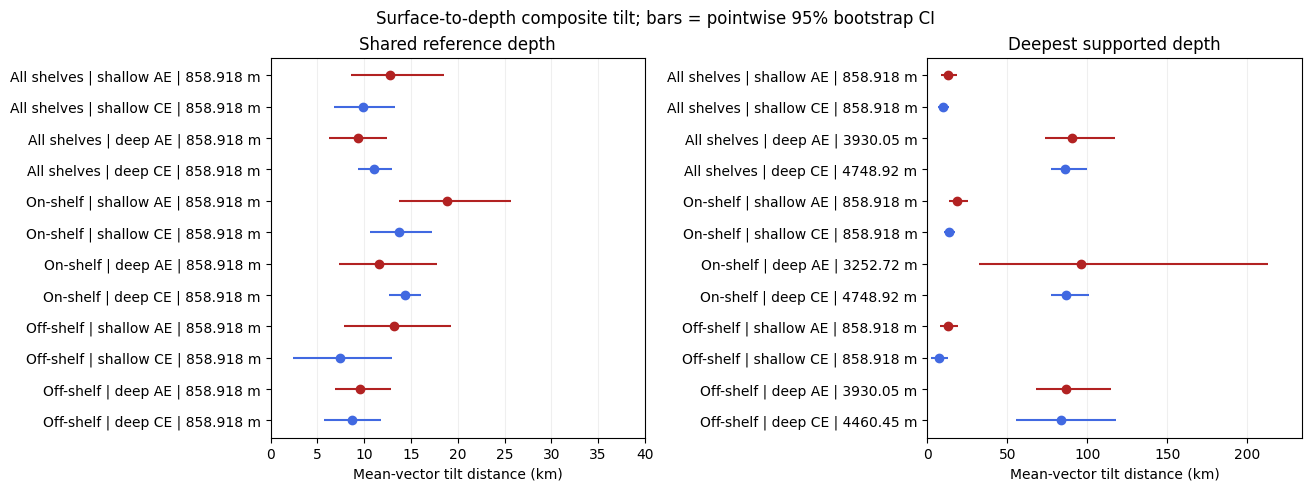

In [11]:
SUMMARY_TARGET_DEPTH_M = 850.0
SUMMARY_DEPTH_TOLERANCE_M = 100.0
tilt_summary = ccomp.tilt_summary(comparison_sets,
    target_depth=SUMMARY_TARGET_DEPTH_M, depth_tolerance=SUMMARY_DEPTH_TOLERANCE_M,
    min_eddies=MIN_PLOT_EDDIES)
with pd.option_context('display.max_rows',None,'display.max_columns',None):
    display(tilt_summary.round(3))
fig, axs = ccomp.plot_tilt_summary(tilt_summary)
axs[0].set_xlim(0,40)
plt.show()


### Composite ESP structure with depth: inner w, outer Omega and Rc
Fit **each composite velocity field itself**, using the same DOPPIO inner-core + ESP outer-core routines as `composite_breakdown`. These are not averages of constituent ESP parameters. `w` is the inner fit's vorticity estimate, `Omega` is the outer ESP rotation parameter (both s⁻¹), and `Rc` is km. The full fitted field's central vorticity `w_full_fit = Omega × trace(Q)` is also available in `composite_esp_fits`.

Only levels meeting the minimum contributing-eddy count are eligible. Failed fits retain their reason and leave gaps; no fit is interpolated. The fourth panel shows local vector R² to help distinguish a representative ESP fit from a poor one. These parameter curves have no fitted-parameter confidence bands: constituent-centre bootstrap intervals do not measure uncertainty in an ESP refit. Coordinates remain in the composite's native frame; scalar w, Omega and Rc are rotation invariant.

`RUN_COMPOSITE_FITS=False` skips this step; velocity reconstruction must be enabled to fit. The fits below are separate from the mean-constituent tilt estimator.


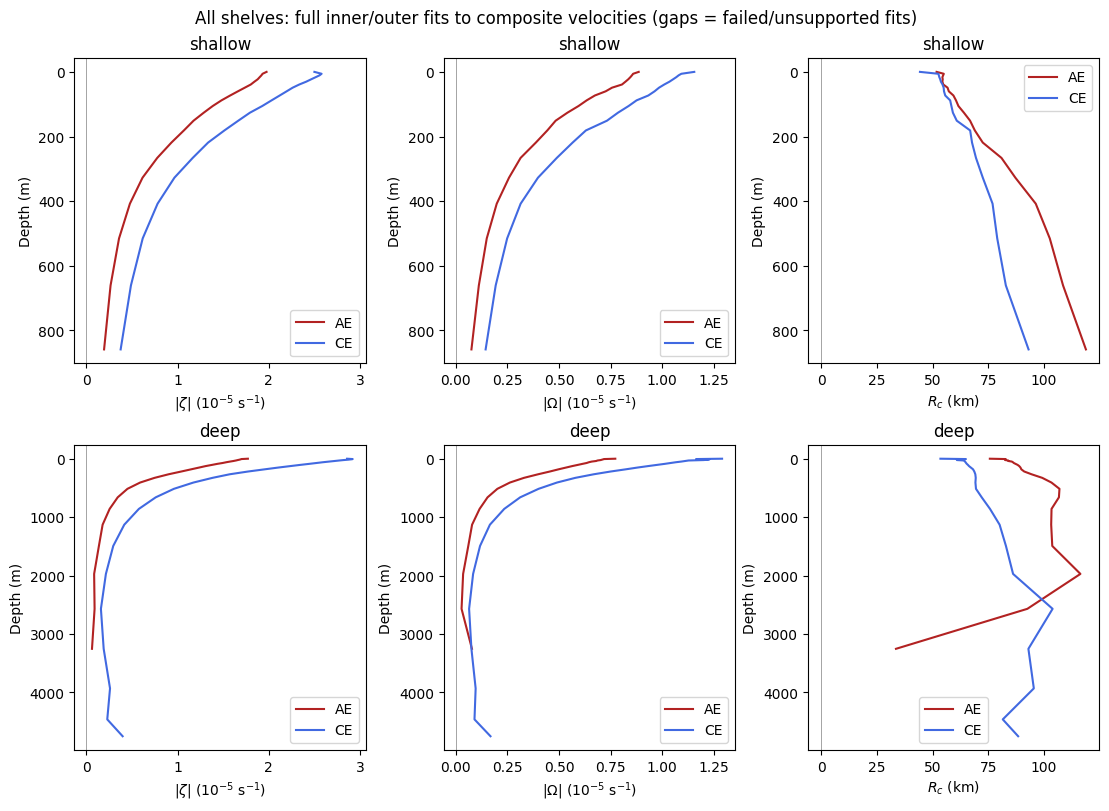

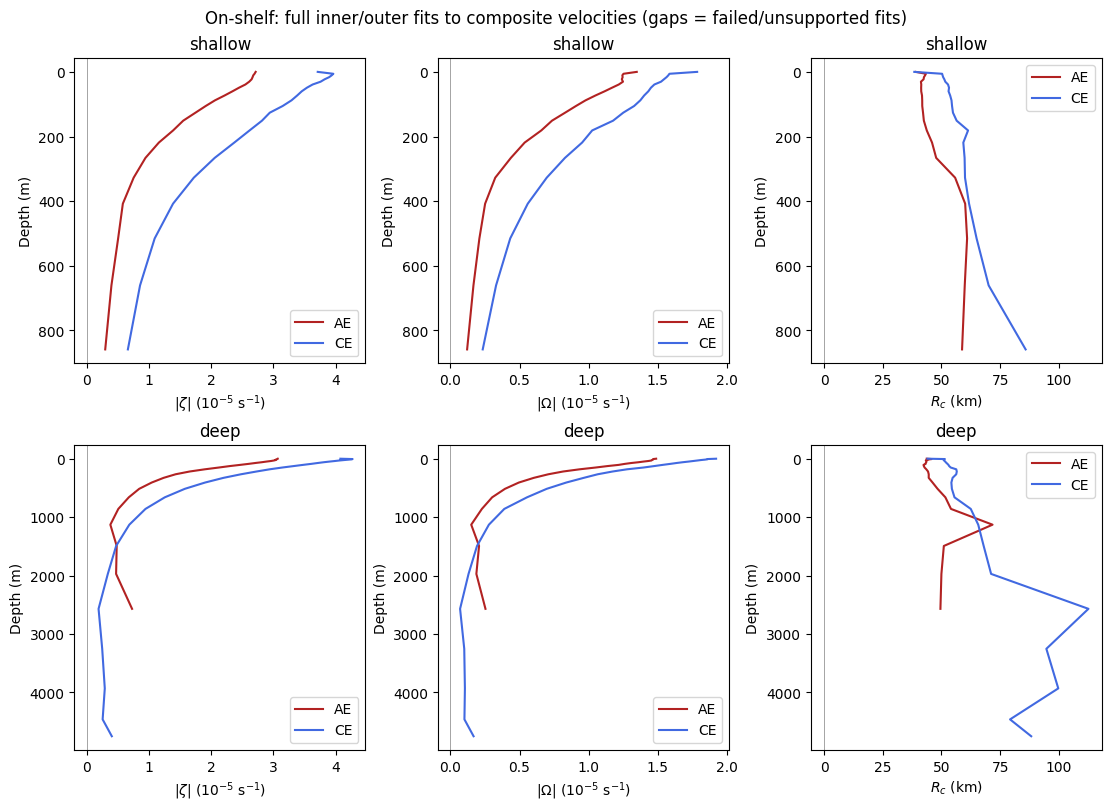

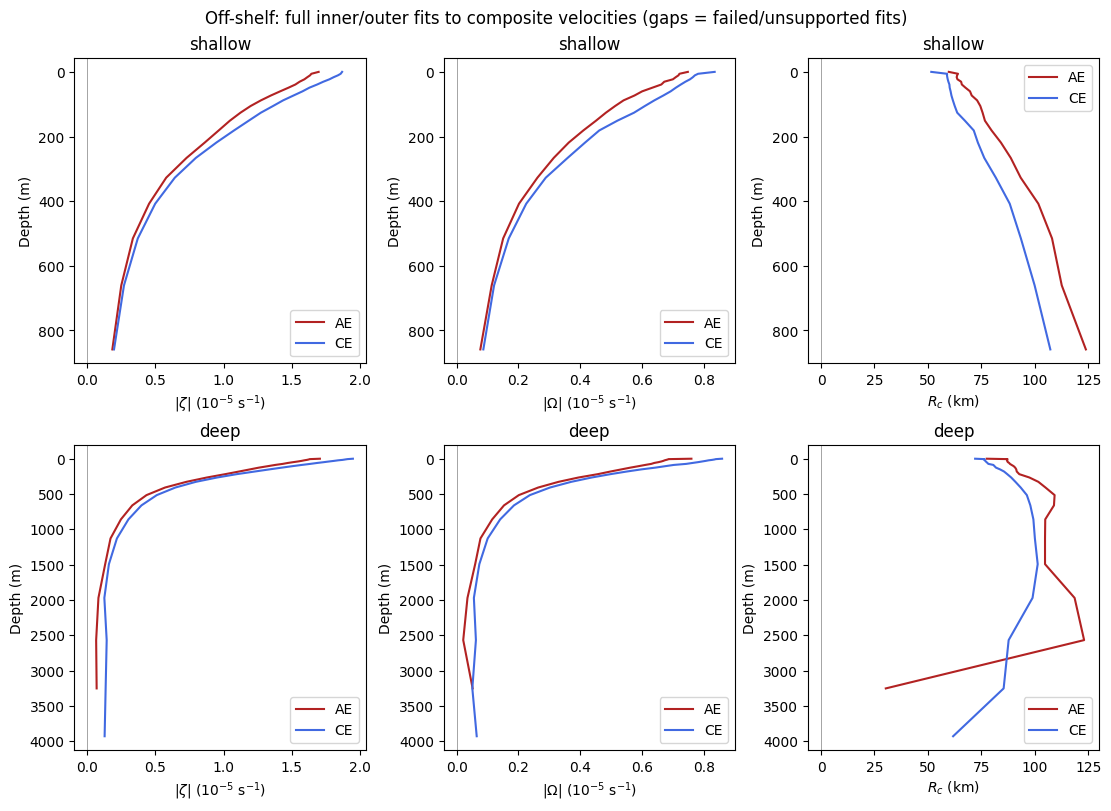

In [19]:
RUN_COMPOSITE_FITS = True
FIT_TRANSECT_RADIUS_KM = 30.0
FIT_RHO_MIN_KM, FIT_RHO_MAX_KM = 30.0, 200.0
FIT_OUT_CORE_FACTOR = 1.75
FIT_MAX_CENTRE_JUMP_KM = 100.0
FIT_MIN_CELL_DAYS = 1
composite_esp_fits = pd.DataFrame()
composite_fit_audit = pd.DataFrame()
if RUN_COMPOSITE_FITS:
    composite_esp_fits, composite_fit_audit = ccomp.fit_collections(
        comparison_sets,X,Y,esp,min_eddies=MIN_PLOT_EDDIES,
        transect_radius_km=FIT_TRANSECT_RADIUS_KM,
        rho_min_km=FIT_RHO_MIN_KM,rho_max_km=FIT_RHO_MAX_KM,
        out_core_fac=FIT_OUT_CORE_FACTOR,max_jump_km=FIT_MAX_CENTRE_JUMP_KM,
        min_cell_days=FIT_MIN_CELL_DAYS)
    # display(composite_fit_audit)
    if not composite_esp_fits.empty:
        # display(composite_esp_fits)
        # display(composite_esp_fits.loc[~composite_esp_fits.fit_ok,
        #     ['population','cohort','Cyc','Depth','reason']])
        for population in composite_esp_fits.population.unique():
            ccomp.plot_fit_profiles(composite_esp_fits,population)
            plt.show()
else:
    print('Composite ESP fits skipped.')


### Vertical velocity sections through the surface centre
Each row shows one polarity. The first panel is the x-directed cut through y = 0, coloured by transverse (y) velocity; the second is the y-directed cut through x = 0, coloured by x velocity. This shows both sides of the rotating core and the zero-velocity structure, complementing the horizontal speed maps. Colours share a symmetric m/s scale within each AE/CE comparison; black contours mark zero velocity.

Here x is along the signed topographic PV gradient and y is its anticlockwise perpendicular. These are cuts along/across that vector, using the same rotated composite velocities as the horizontal maps.

Cuts remain anchored at the surface centre; they do not follow the moving deeper centre. A strongly tilted core can therefore move out of a cut. Unsupported depths/cells stay blank. Use `SECTION_COHORTS` and `SECTION_POPULATIONS` to control the displayed comparisons.


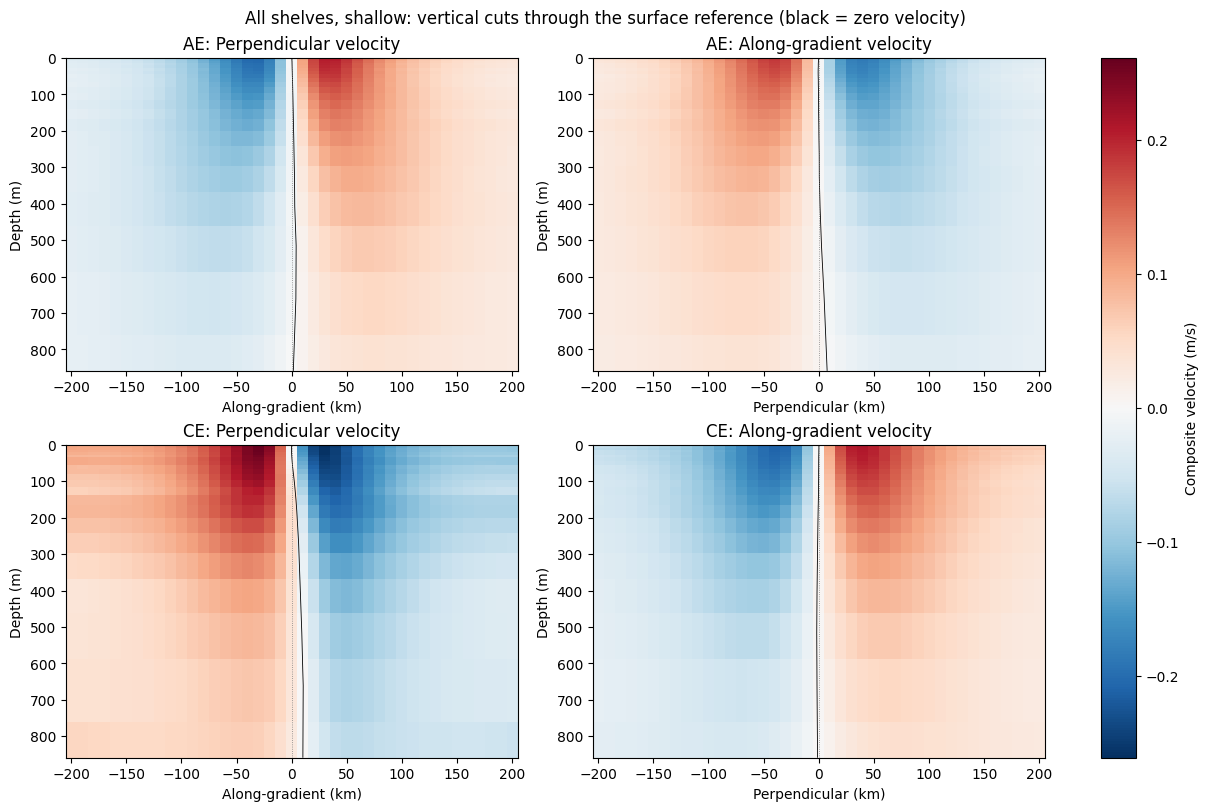

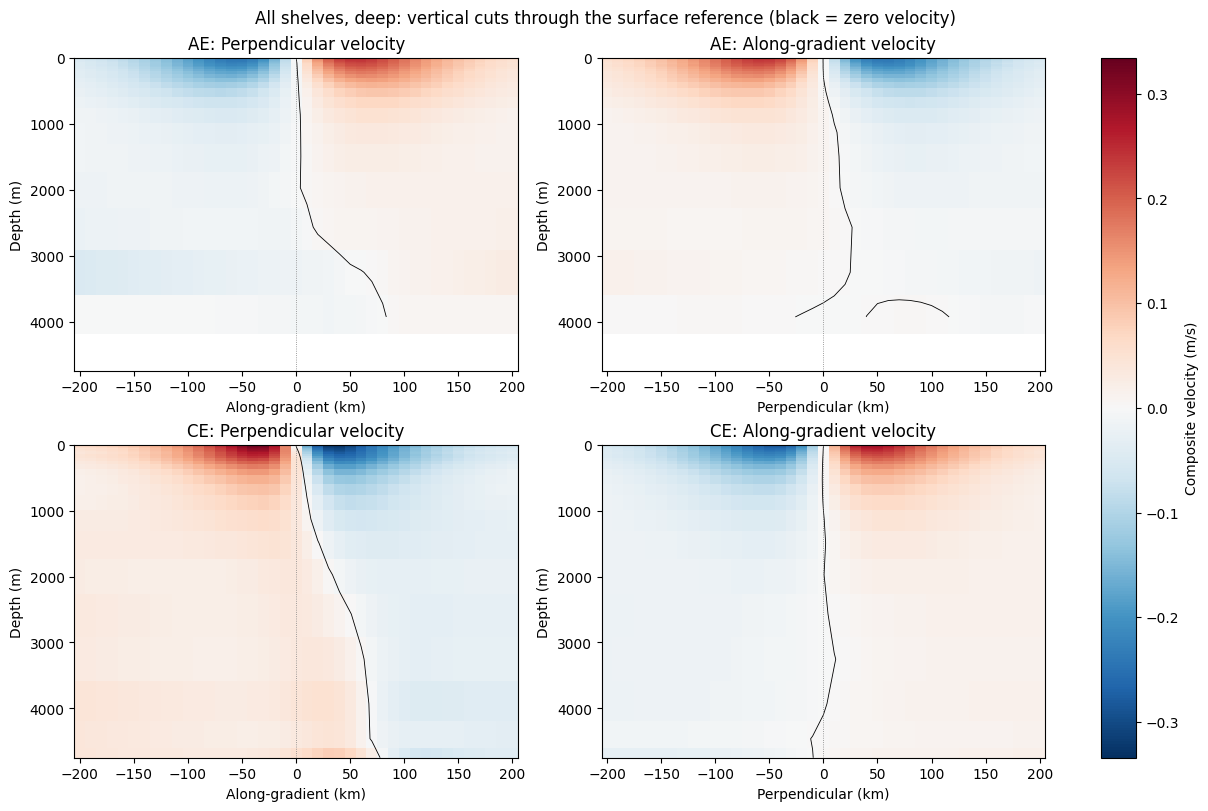

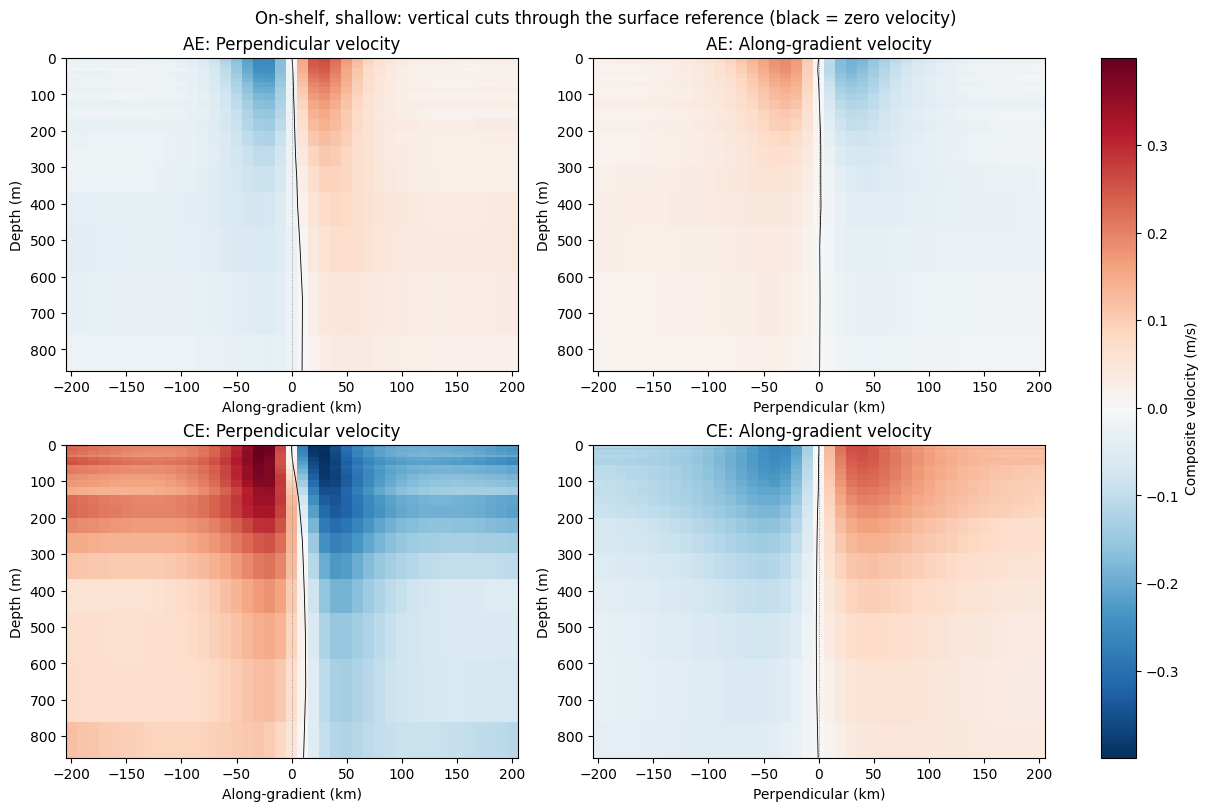

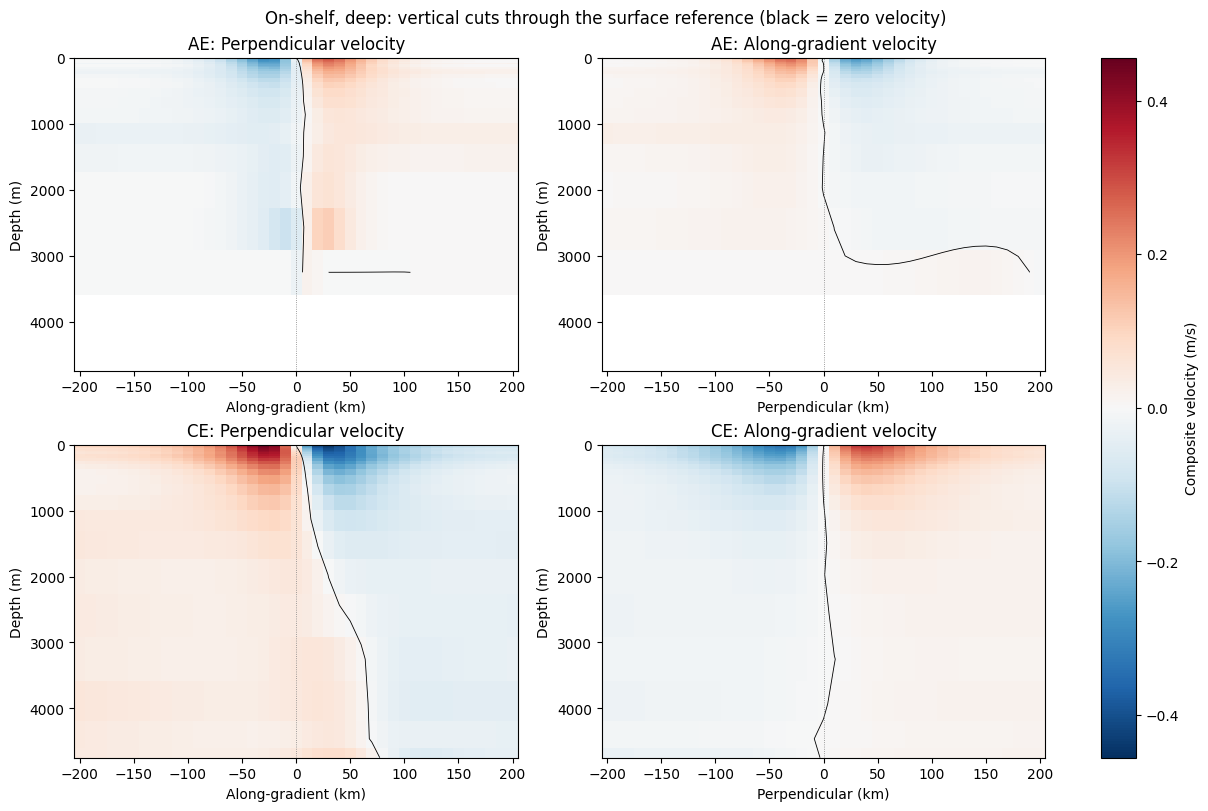

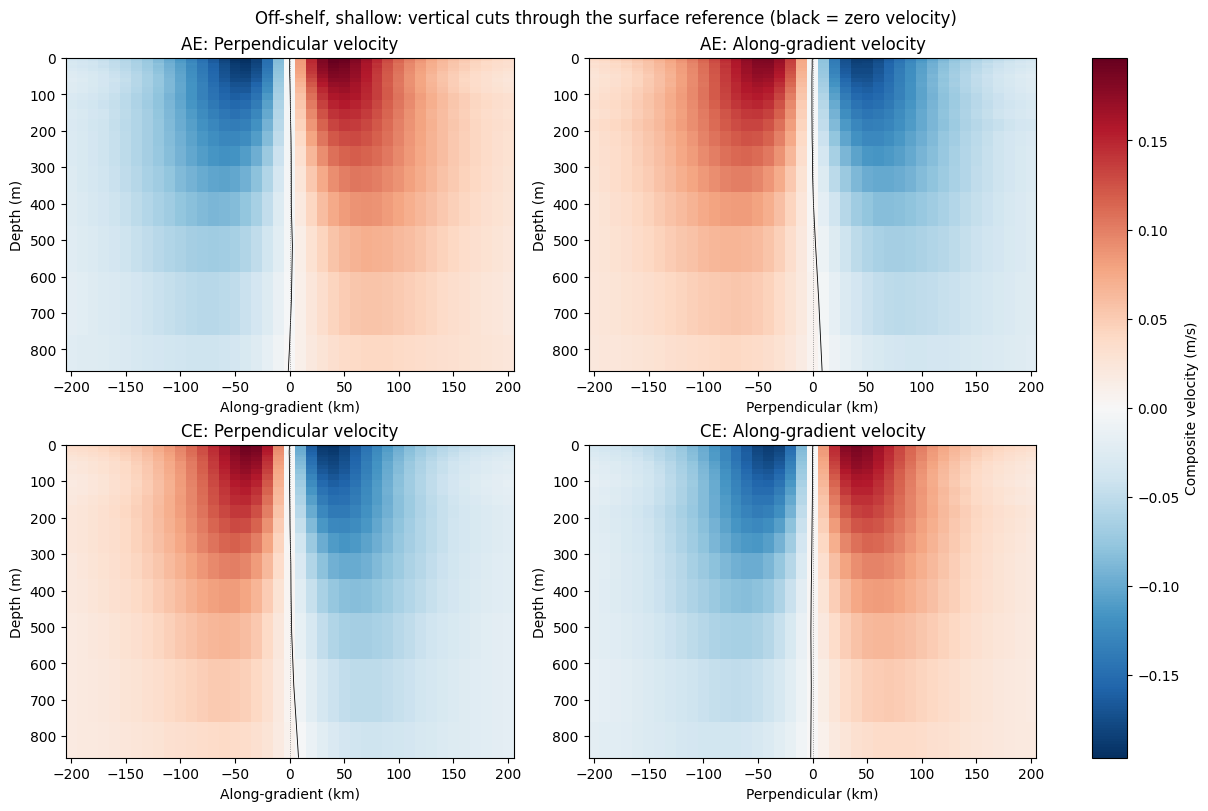

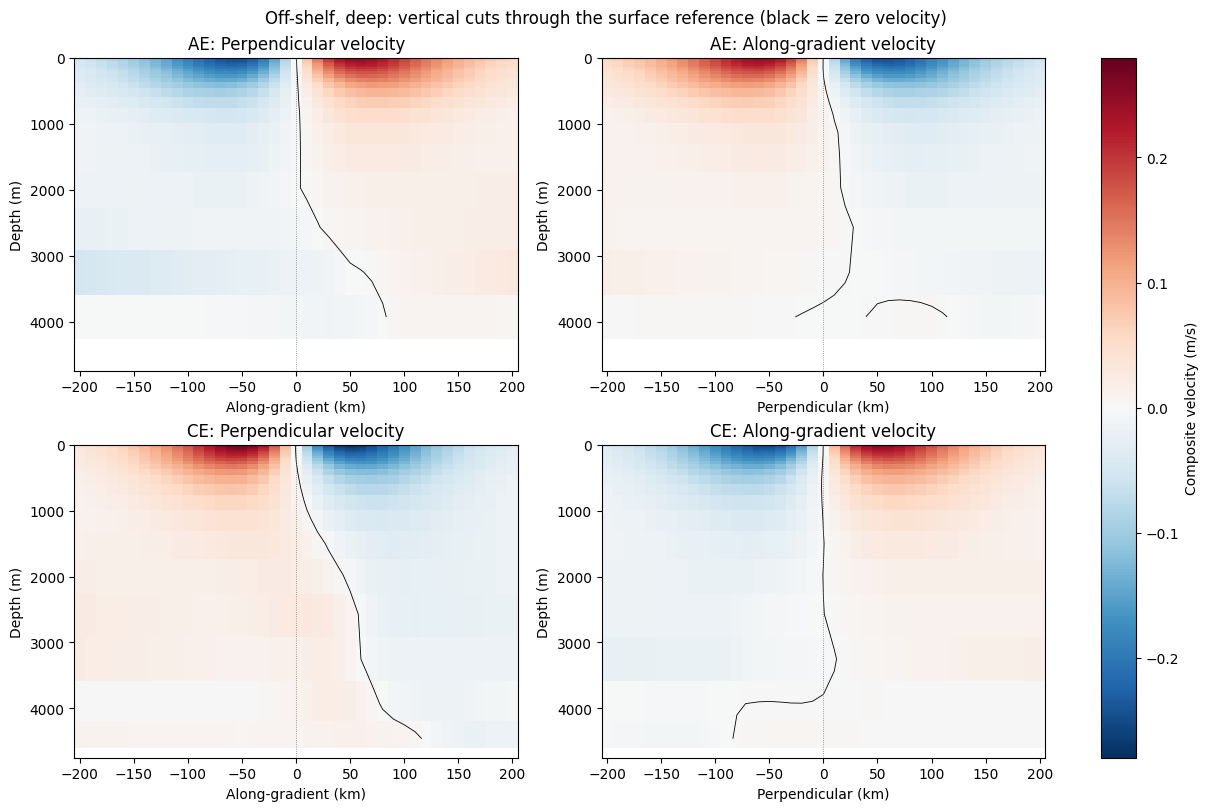

In [13]:
SECTION_POPULATIONS = ['All shelves','On-shelf','Off-shelf']
SECTION_COHORTS = ['shallow','deep']
for population in SECTION_POPULATIONS:
    for cohort in SECTION_COHORTS:
        fig = ccomp.plot_sections(comparison_sets[population],X,Y,population,cohort,
            rotation_rad=0.0,frame='topographic',
            min_eddies=MIN_PLOT_EDDIES)
        if fig is not None: plt.show()
        else: print(population,cohort,': no reconstructed velocity fields')


### Optional comparison-table export
The summary, full ESP fits and fit-status table remain available in memory. These exports overwrite only the comparison tables below; existing constituent and profile tables are unchanged.


In [14]:
SAVE_COMPARISON_TABLES = False
if SAVE_COMPARISON_TABLES:
    out=Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/topographic_composite_tilt')
    out.mkdir(parents=True,exist_ok=True)
    tilt_summary.to_csv(out/'tilt_summary.csv',index=False)
    composite_esp_fits.to_csv(out/'composite_esp_fits.csv',index=False)
    composite_fit_audit.to_csv(out/'composite_fit_audit.csv',index=False)
    shelf_centre_stats.to_parquet(out/'shelf_centre_stats.parquet',index=False)
    (out/'comparison_settings.json').write_text(json.dumps(dict(
        summary_target_depth_m=SUMMARY_TARGET_DEPTH_M,summary_tolerance_m=SUMMARY_DEPTH_TOLERANCE_M,
        minimum_eddies=MIN_PLOT_EDDIES,split_depth_m=SPLIT_DEPTH_M,
        shelf_lon=SHELF_LON,grid_angle_rad=float(grid.angle),
        fit_transect_km=FIT_TRANSECT_RADIUS_KM,fit_rho_min_km=FIT_RHO_MIN_KM,
        fit_rho_max_km=FIT_RHO_MAX_KM,fit_out_core_factor=FIT_OUT_CORE_FACTOR,
        fit_max_jump_km=FIT_MAX_CENTRE_JUMP_KM,fit_min_cell_days=FIT_MIN_CELL_DAYS),indent=2))
    print(out)
